# Análisis Exploratorio de Datos (EDA) - Boletín Epidemiológico 2000-2025

Este notebook unifica y analiza los datos del Boletín Epidemiológico de México desde el año 2000 hasta 2025.

## 1. Importar Librerías

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
base_path = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
raw_data_path = f'{base_path}/data/raw/'
processed_data_path = f'{base_path}/data/processed/'
print(f"Ruta de datos en bruto: {raw_data_path}")
print(f"Ruta de datos procesados: {processed_data_path}")

# Definir la ruta a la carpeta con los archivos CSV
BOLETIN_FOLDER_PATH = f'{raw_data_path}boletin_epidemiologico_2000_2025'

Ruta de datos en bruto: /home/gerardo/maestria/proyecto_terminal/data/raw/
Ruta de datos procesados: /home/gerardo/maestria/proyecto_terminal/data/processed/


## 2. Cargar y Unificar Todos los Datasets

Cargamos todos los archivos CSV del Boletín Epidemiológico (2000-2025) y los consolidamos en un único DataFrame.

### ⚠️ Problema Identificado con el Año 2004

El archivo CSV del año 2004 tiene **espacios después de las comas** en el encabezado, lo que causa que las columnas se lean con espacios al inicio (ejemplo: " Semana" en lugar de "Semana"). Esto genera columnas duplicadas al concatenar.

**Solución:** Usaremos `skipinitialspace=True` al leer los CSV para eliminar esos espacios automáticamente.

In [3]:
# Obtener todos los archivos CSV en la carpeta
csv_files = glob.glob(os.path.join(BOLETIN_FOLDER_PATH, "*.csv"))

print(f"Archivos CSV encontrados: {len(csv_files)}")
print("\nPrimeros archivos:")
for file in sorted(csv_files)[:5]:
    print(f"  - {os.path.basename(file)}")

Archivos CSV encontrados: 25

Primeros archivos:
  - 2000_boletin_epi_s1_s52.csv
  - 2001_boletin_epi_s1_s52.csv
  - 2002_boletin_epi_s1_s52.csv
  - 2003_boletin_epi_s1_s53.csv
  - 2004_boletin_epi_s1_s52.csv


In [4]:
# Cargar y concatenar todos los archivos CSV
dataframes = []

for file in sorted(csv_files):
    try:
        # Leer el archivo CSV con skipinitialspace=True para manejar el problema del año 2004
        # que tiene espacios después de las comas en el encabezado
        df = pd.read_csv(file, encoding='utf-8', skipinitialspace=True)
        dataframes.append(df)
        print(f"✓ Cargado: {os.path.basename(file)} - {len(df)} registros")
    except Exception as e:
        print(f"✗ Error al cargar {os.path.basename(file)}: {str(e)}")

# Concatenar todos los DataFrames
df_unificado = pd.concat(dataframes, ignore_index=True)

print(f"\n{'='*60}")
print(f"Dataset unificado creado exitosamente")
print(f"Total de registros: {len(df_unificado):,}")
print(f"Total de columnas: {len(df_unificado.columns)}")
print(f"{'='*60}")

✓ Cargado: 2000_boletin_epi_s1_s52.csv - 375 registros
✓ Cargado: 2001_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2002_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2003_boletin_epi_s1_s53.csv - 636 registros
✓ Cargado: 2004_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2005_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2006_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2007_boletin_epi_s1_s52.csv - 636 registros
✓ Cargado: 2008_boletin_epi_s1_s52.csv - 636 registros
✓ Cargado: 2009_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2010_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2012_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2013_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2014_boletin_epi_s1_s53.csv - 636 registros
✓ Cargado: 2015_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2016_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2017_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado: 2018_boletin_epi_s1_s52.csv - 624 registros
✓ Cargado:

In [5]:
# Verificar que todas las columnas estén correctas
print(f"\n{'='*60}")
print("COLUMNAS DEL DATASET UNIFICADO:")
print(f"{'='*60}")
for i, col in enumerate(df_unificado.columns, 1):
    print(f"{i}. '{col}'")
print(f"{'='*60}")


COLUMNAS DEL DATASET UNIFICADO:
1. 'Año'
2. 'Semana'
3. 'Enfermedad'
4. 'CIE_10'
5. 'Variable'
6. 'Valor'
7. 'Fuente_Cuadro'
8. 'Nivel'


## 3. Exploración Inicial del Dataset Unificado

In [6]:
# Información general del dataset
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
df_unificado.info()
print("\n" + "="*60)

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15363 entries, 0 to 15362
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Año            15363 non-null  int64 
 1   Semana         15363 non-null  int64 
 2   Enfermedad     15363 non-null  object
 3   CIE_10         15363 non-null  object
 4   Variable       15363 non-null  object
 5   Valor          15363 non-null  object
 6   Fuente_Cuadro  15363 non-null  object
 7   Nivel          15363 non-null  object
dtypes: int64(2), object(6)
memory usage: 960.3+ KB



In [7]:
# Primeras filas del dataset
print("PRIMERAS 10 FILAS DEL DATASET")
print("="*60)
display(df_unificado.head(10))

PRIMERAS 10 FILAS DEL DATASET


,Año,Semana,Enfermedad,CIE_10,Variable,Valor,Fuente_Cuadro,Nivel
0,2000,1,Sarampión,B05,Casos_Semana_Actual,0,Cuadro_Vacunación,Nacional
1,2000,1,Sarampión,B05,Acumulado_Año_Actual,0,Cuadro_Vacunación,Nacional
2,2000,1,Sarampión,B05,Acumulado_Año_Anterior,0,Cuadro_Vacunación,Nacional
3,2000,1,Tuberculosis respiratoria,A15-A16,Casos_Semana_Actual,144,Otras_Notificación_Semanal,Nacional
4,2000,1,Tuberculosis respiratoria,A15-A16,Acumulado_Año_Actual,144,Otras_Notificación_Semanal,Nacional
5,2000,1,Tuberculosis respiratoria,A15-A16,Acumulado_Año_Anterior,213,Otras_Notificación_Semanal,Nacional
6,2000,1,Tuberculosis meníngea,A17.0,Casos_Semana_Actual,3,Otras_Notificación_Semanal,Nacional
7,2000,1,Tuberculosis meníngea,A17.0,Acumulado_Año_Actual,3,Otras_Notificación_Semanal,Nacional
8,2000,1,Tuberculosis meníngea,A17.0,Acumulado_Año_Anterior,12,Otras_Notificación_Semanal,Nacional
9,2000,1,Hepatitis B,B16,Casos_Semana_Actual,5,Otras_Notificación_Semanal,Nacional


In [8]:
# Estadísticas descriptivas
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
display(df_unificado.describe())

print("\nESTADÍSTICAS DE VARIABLES CATEGÓRICAS")
print("="*60)
display(df_unificado.describe(include='object'))

ESTADÍSTICAS DESCRIPTIVAS


,Año,Semana
count,15363.000000,15363.000000
mean,2012.716266,26.275923
std,7.510190,15.013606
min,2000.000000,1.000000
25%,2006.000000,13.000000
50%,2013.000000,26.000000
75%,2019.000000,39.000000
max,2025.000000,53.000000



ESTADÍSTICAS DE VARIABLES CATEGÓRICAS


,Enfermedad,CIE_10,Variable,Valor,Fuente_Cuadro,Nivel
count,15363,15363,15363,15363,15363,15363
unique,4,6,3,3447,56,6
top,Hepatitis B,B05,Casos_Semana_Actual,0,Cuadro 2,Nacional
freq,3888,3825,5121,1818,2796,15303


In [9]:
# Valores únicos por columna
print("VALORES ÚNICOS POR COLUMNA")
print("="*60)
for col in df_unificado.columns:
    n_unique = df_unificado[col].nunique()
    print(f"{col:25s}: {n_unique:6,} valores únicos")

print("\n" + "="*60)
print(f"\nAños disponibles: {sorted(df_unificado['Año'].unique())}")
print(f"Rango de años: {df_unificado['Año'].min()} - {df_unificado['Año'].max()}")

VALORES ÚNICOS POR COLUMNA
Año                      :     25 valores únicos
Semana                   :     53 valores únicos
Enfermedad               :      4 valores únicos
CIE_10                   :      6 valores únicos
Variable                 :      3 valores únicos
Valor                    :  3,447 valores únicos
Fuente_Cuadro            :     56 valores únicos
Nivel                    :      6 valores únicos


Años disponibles: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Rango de años: 2000 - 2025


In [10]:
# Verificar valores nulos
print("VALORES NULOS POR COLUMNA")
print("="*60)
nulls = df_unificado.isnull().sum()
null_percent = (nulls / len(df_unificado)) * 100

null_df = pd.DataFrame({
    'Columna': nulls.index,
    'Valores Nulos': nulls.values,
    'Porcentaje': null_percent.values
})
null_df = null_df[null_df['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)

if len(null_df) > 0:
    display(null_df)
else:
    print("✓ No se encontraron valores nulos en el dataset")

VALORES NULOS POR COLUMNA
✓ No se encontraron valores nulos en el dataset


In [11]:
# Enfermedades incluidas en el dataset
print("ENFERMEDADES INCLUIDAS EN EL DATASET")
print("="*60)
enfermedades = df_unificado[['Enfermedad', 'CIE_10']].drop_duplicates().sort_values('Enfermedad')
print(f"Total de enfermedades: {len(enfermedades)}\n")
display(enfermedades.reset_index(drop=True))

ENFERMEDADES INCLUIDAS EN EL DATASET
Total de enfermedades: 6



,Enfermedad,CIE_10
0,Hepatitis B,B16
1,Hepatitis B,B16-B18.0-B18.1
2,Hepatitis B,B16-B18.1
3,Sarampión,B05
4,Tuberculosis meníngea,A17.0
5,Tuberculosis respiratoria,A15-A16


## 4. Guardar el Dataset Unificado

Guardamos el dataset consolidado en formato CSV para análisis posteriores.

In [12]:
# Guardar el dataset unificado
output_file = f"{processed_data_path}boletin_epidemiologico_2000-2025_unificado.csv"

df_unificado.to_csv(output_file, index=False, encoding='utf-8')

print(f"✓ Dataset unificado guardado exitosamente en: {output_file}")
print(f"  Total de registros: {len(df_unificado):,}")
print(f"  Tamaño del archivo: {os.path.getsize(output_file) / (1024*1024):.2f} MB")

✓ Dataset unificado guardado exitosamente en: /home/gerardo/maestria/proyecto_terminal/data/processed/boletin_epidemiologico_2000-2025_unificado.csv
  Total de registros: 15,363
  Tamaño del archivo: 1.23 MB


## 5. Análisis Exploratorio de Datos (EDA) Profundo

Realizamos un análisis detallado del dataset para identificar patrones, tendencias y características relevantes.

### 5.1 Análisis Temporal - Evolución de Casos por Año

In [13]:
# Filtrar solo los casos de la semana actual para análisis temporal
casos_semana = df_unificado[df_unificado['Variable'] == 'Casos_Semana_Actual'].copy()

# Convertir la columna 'Valor' a numérica (valores no numéricos como 'ND' se convierten a NaN)
casos_semana['Valor'] = pd.to_numeric(casos_semana['Valor'], errors='coerce')

# Eliminar filas con valores NaN (que eran 'ND' u otros valores no numéricos)
casos_semana = casos_semana.dropna(subset=['Valor'])

# Agrupar casos por año y enfermedad
casos_por_año = casos_semana.groupby(['Año', 'Enfermedad'])['Valor'].sum().reset_index()

# Top 10 enfermedades con más casos totales
top_enfermedades = casos_por_año.groupby('Enfermedad')['Valor'].sum().nlargest(10).index.tolist()

print("TOP 10 ENFERMEDADES CON MÁS CASOS (2000-2025):")
print("="*60)
for i, enf in enumerate(top_enfermedades, 1):
    total = casos_por_año[casos_por_año['Enfermedad'] == enf]['Valor'].sum()
    print(f"{i:2d}. {enf:40s}: {total:>12,.0f} casos")
print("="*60)

TOP 10 ENFERMEDADES CON MÁS CASOS (2000-2025):
 1. Tuberculosis respiratoria               :      383,605 casos
 2. Hepatitis B                             :       14,477 casos
 3. Tuberculosis meníngea                   :        6,218 casos
 4. Sarampión                               :        1,292 casos


In [14]:
# Resumen final del análisis
print("="*80)
print(" " * 20 + "RESUMEN EJECUTIVO DEL ANÁLISIS")
print("="*80)
print()

# Estadísticas generales
total_casos = casos_semana['Valor'].sum()
total_enfermedades = df_unificado['Enfermedad'].nunique()
años_analizados = df_unificado['Año'].nunique()
promedio_casos_anual = total_casos / años_analizados

print(f"📊 ESTADÍSTICAS GENERALES:")
print(f"   • Total de casos registrados (2000-2025): {total_casos:,}")
print(f"   • Número de enfermedades monitoreadas: {total_enfermedades}")
print(f"   • Años analizados: {años_analizados} ({df_unificado['Año'].min()}-{df_unificado['Año'].max()})")
print(f"   • Promedio de casos por año: {promedio_casos_anual:,.0f}")
print()

# Enfermedad más prevalente
enfermedad_top = casos_por_año.groupby('Enfermedad')['Valor'].sum().idxmax()
casos_top = casos_por_año.groupby('Enfermedad')['Valor'].sum().max()
print(f"🔝 ENFERMEDAD MÁS PREVALENTE:")
print(f"   • {enfermedad_top}")
print(f"   • Total de casos: {casos_top:,}")
print()

# Año con más casos
año_max = casos_semana.groupby('Año')['Valor'].sum().idxmax()
casos_año_max = casos_semana.groupby('Año')['Valor'].sum().max()
print(f"📈 AÑO CON MÁS CASOS REGISTRADOS:")
print(f"   • Año: {año_max}")
print(f"   • Total de casos: {casos_año_max:,}")
print()

# Año con menos casos
año_min = casos_semana.groupby('Año')['Valor'].sum().idxmin()
casos_año_min = casos_semana.groupby('Año')['Valor'].sum().min()
print(f"📉 AÑO CON MENOS CASOS REGISTRADOS:")
print(f"   • Año: {año_min}")
print(f"   • Total de casos: {casos_año_min:,}")
print()

print("="*80)
print("✅ Análisis exploratorio completado exitosamente")
print("="*80)

                    RESUMEN EJECUTIVO DEL ANÁLISIS

📊 ESTADÍSTICAS GENERALES:
   • Total de casos registrados (2000-2025): 405,592.0
   • Número de enfermedades monitoreadas: 4
   • Años analizados: 25 (2000-2025)
   • Promedio de casos por año: 16,224

🔝 ENFERMEDAD MÁS PREVALENTE:
   • Tuberculosis respiratoria
   • Total de casos: 383,605.0

📈 AÑO CON MÁS CASOS REGISTRADOS:
   • Año: 2023
   • Total de casos: 22,768.0

📉 AÑO CON MENOS CASOS REGISTRADOS:
   • Año: 2000
   • Total de casos: 6,202.0

✅ Análisis exploratorio completado exitosamente


### 5.7 Resumen Ejecutivo del Análisis

TASAS DE CRECIMIENTO (2000 vs 2025)


,Enfermedad,Casos_2000,Casos_2025,Cambio_Absoluto,Cambio_Porcentual
0,Tuberculosis respiratoria,5313.0,18311.0,12998.0,244.645210
2,Tuberculosis meníngea,240.0,480.0,240.0,100.000000
1,Hepatitis B,649.0,604.0,-45.0,-6.933744


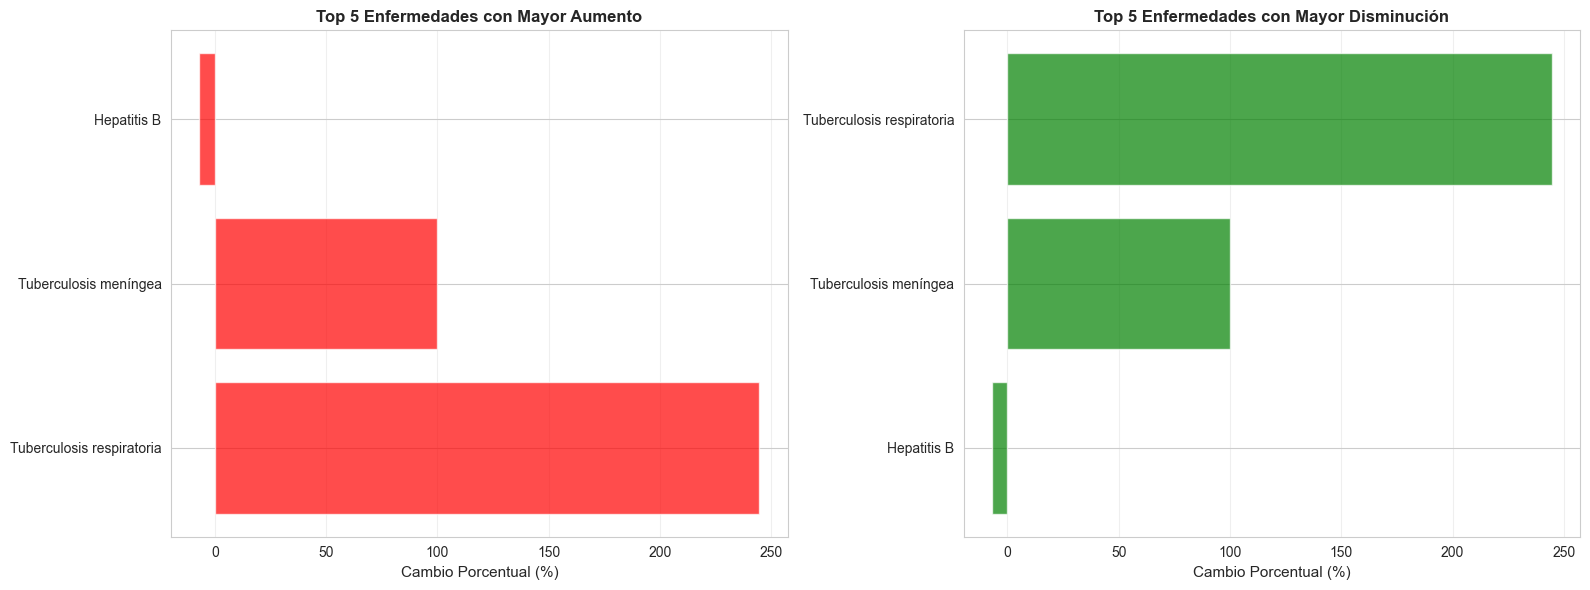

In [15]:
# Calcular tasa de crecimiento entre 2000 y 2025 para cada enfermedad
print("TASAS DE CRECIMIENTO (2000 vs 2025)")
print("="*80)

crecimiento = []
for enfermedad in top_enfermedades:
    casos_2000 = casos_por_año[(casos_por_año['Enfermedad'] == enfermedad) &
                               (casos_por_año['Año'] == 2000)]['Valor'].sum()
    casos_2025 = casos_por_año[(casos_por_año['Enfermedad'] == enfermedad) &
                               (casos_por_año['Año'] == 2025)]['Valor'].sum()

    if casos_2000 > 0:
        tasa = ((casos_2025 - casos_2000) / casos_2000) * 100
        crecimiento.append({
            'Enfermedad': enfermedad,
            'Casos_2000': casos_2000,
            'Casos_2025': casos_2025,
            'Cambio_Absoluto': casos_2025 - casos_2000,
            'Cambio_Porcentual': tasa
        })

crec_df = pd.DataFrame(crecimiento).sort_values('Cambio_Porcentual', ascending=False)
display(crec_df)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Enfermedades con mayor aumento
aumentos = crec_df.nlargest(5, 'Cambio_Porcentual')
ax1.barh(aumentos['Enfermedad'].str[:30], aumentos['Cambio_Porcentual'], color='red', alpha=0.7)
ax1.set_xlabel('Cambio Porcentual (%)', fontsize=11)
ax1.set_title('Top 5 Enfermedades con Mayor Aumento', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Enfermedades con mayor disminución
disminuciones = crec_df.nsmallest(5, 'Cambio_Porcentual')
ax2.barh(disminuciones['Enfermedad'].str[:30], disminuciones['Cambio_Porcentual'], color='green', alpha=0.7)
ax2.set_xlabel('Cambio Porcentual (%)', fontsize=11)
ax2.set_title('Top 5 Enfermedades con Mayor Disminución', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 5.6 Análisis de Crecimiento y Tasas de Cambio

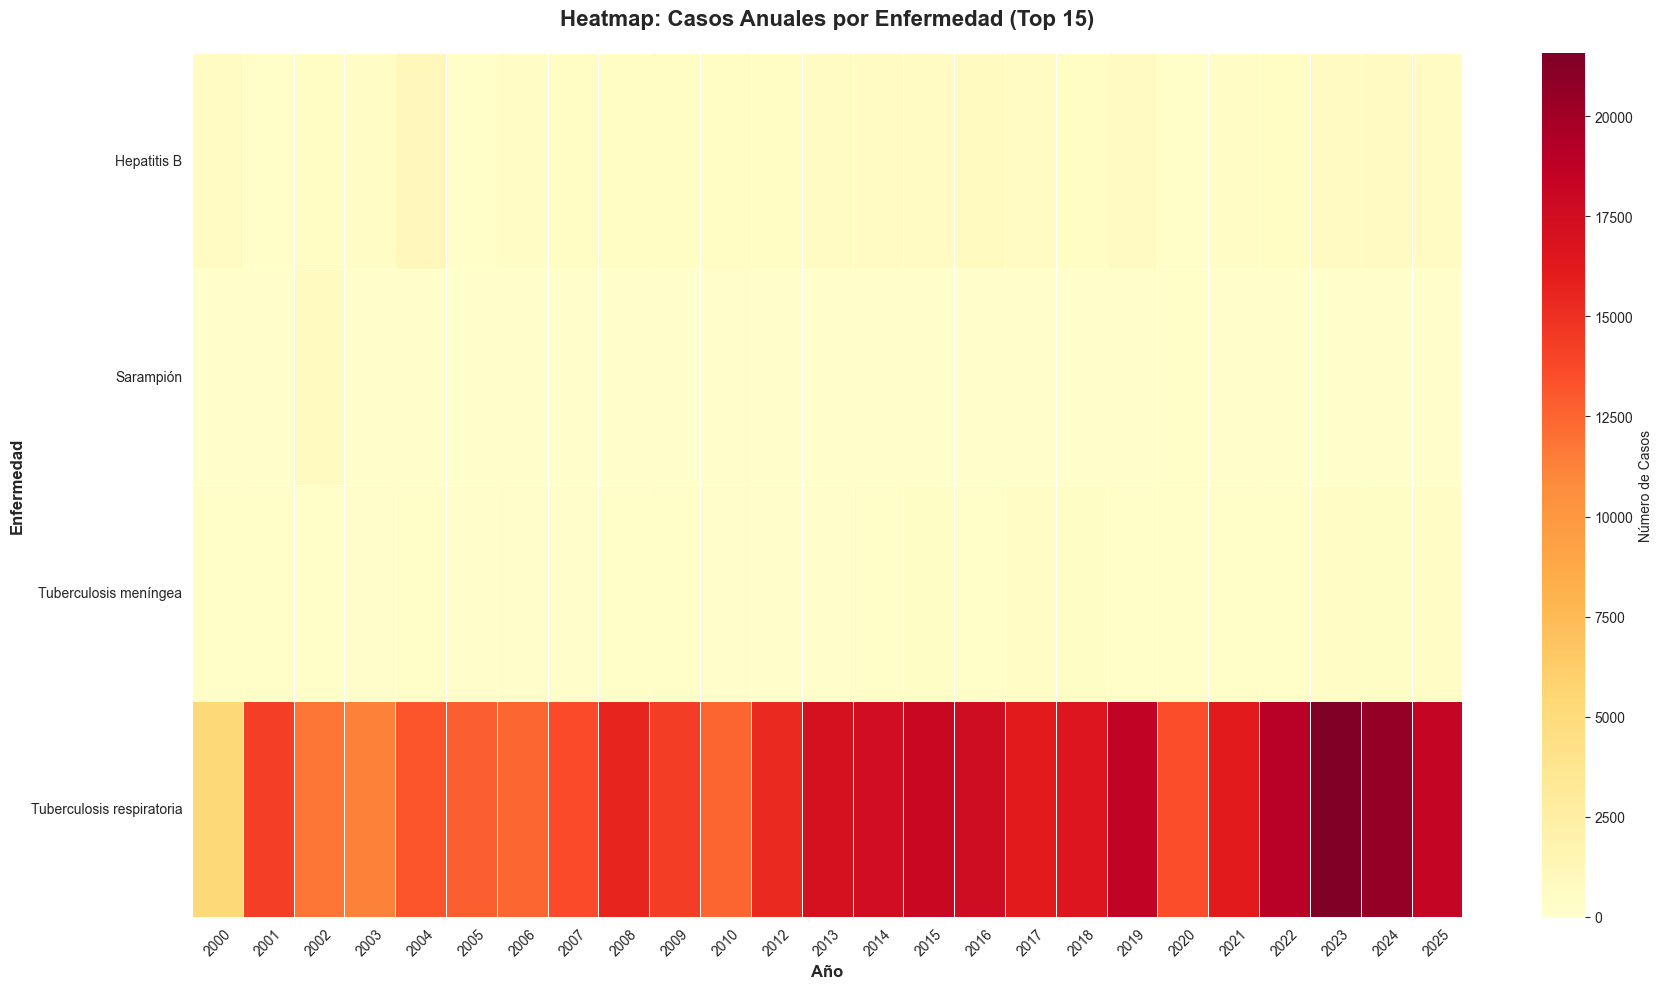

In [16]:
# Crear matriz de casos por año y enfermedad (Top 15 enfermedades)
top_15_enf = casos_por_año.groupby('Enfermedad')['Valor'].sum().nlargest(15).index.tolist()

# Pivot table para el heatmap
heatmap_data = casos_por_año[casos_por_año['Enfermedad'].isin(top_15_enf)].pivot_table(
    index='Enfermedad',
    columns='Año',
    values='Valor',
    fill_value=0
)

# Heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Número de Casos'})
plt.title('Heatmap: Casos Anuales por Enfermedad (Top 15)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12, fontweight='bold')
plt.ylabel('Enfermedad', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.5 Heatmap - Casos Anuales por Enfermedad

DISTRIBUCIÓN DE DATOS POR FUENTE


,Fuente,N_Registros,N_Enfermedades
6,Cuadro 2,2796,3
0,Cuadro 1,2721,4
7,Cuadro 3,1610,3
50,Otras enfermedades de notificación semanal,657,3
44,Cuadro_Vacunación,645,2
11,Cuadro 3.2,612,4
43,Cuadro_Transmisibles,576,3
41,Cuadro_Otras_Enfermedades,471,3
2,Cuadro 11,435,3
54,Otras_Notificación_Semanal,396,3


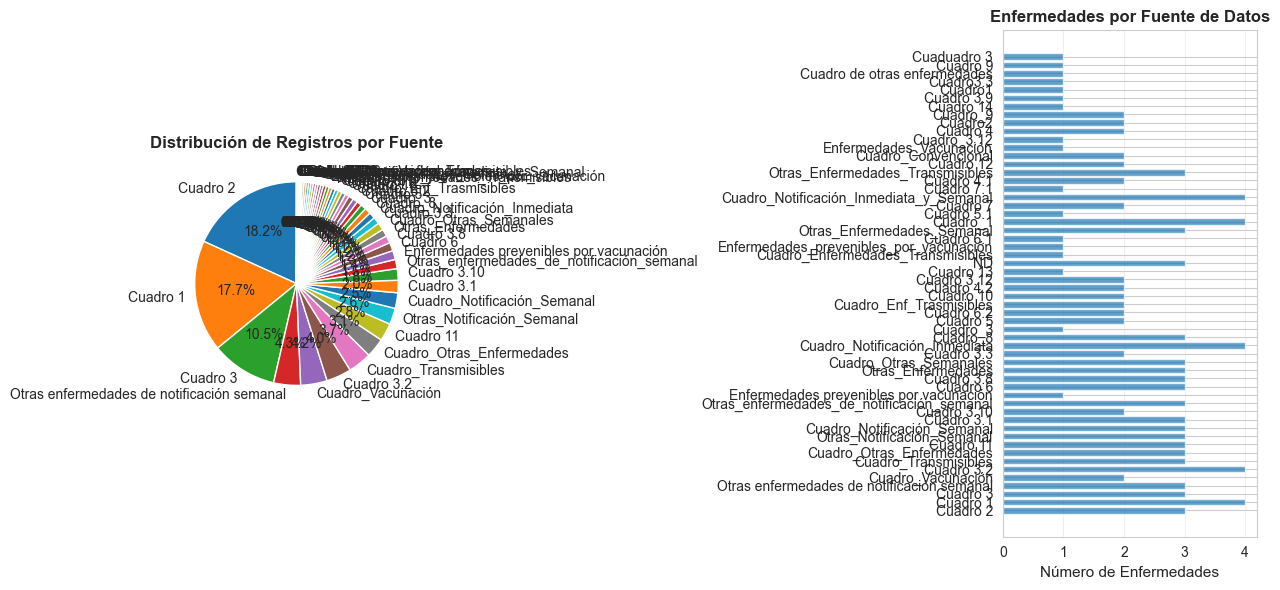

In [17]:
# Análisis por fuente de cuadro
print("DISTRIBUCIÓN DE DATOS POR FUENTE")
print("="*60)

fuentes = df_unificado.groupby('Fuente_Cuadro').agg({
    'Valor': 'count',
    'Enfermedad': 'nunique'
}).reset_index()
fuentes.columns = ['Fuente', 'N_Registros', 'N_Enfermedades']
fuentes = fuentes.sort_values('N_Registros', ascending=False)

display(fuentes)

# Gráfico de pastel
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.pie(fuentes['N_Registros'], labels=fuentes['Fuente'], autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Registros por Fuente', fontsize=12, fontweight='bold')

plt.subplot(1, 2, 2)
plt.barh(fuentes['Fuente'], fuentes['N_Enfermedades'], alpha=0.7)
plt.xlabel('Número de Enfermedades', fontsize=11)
plt.title('Enfermedades por Fuente de Datos', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 5.4 Análisis por Fuente de Datos

COMPARACIÓN DE CASOS POR PERÍODO


,Período,Total_Casos,Promedio_Anual,Años
0,2000-2010,146373.0,13306.636364,2000-2010
1,2011-2020,158662.0,15866.200000,2011-2020
2,2021-2025,100557.0,20111.400000,2021-2025


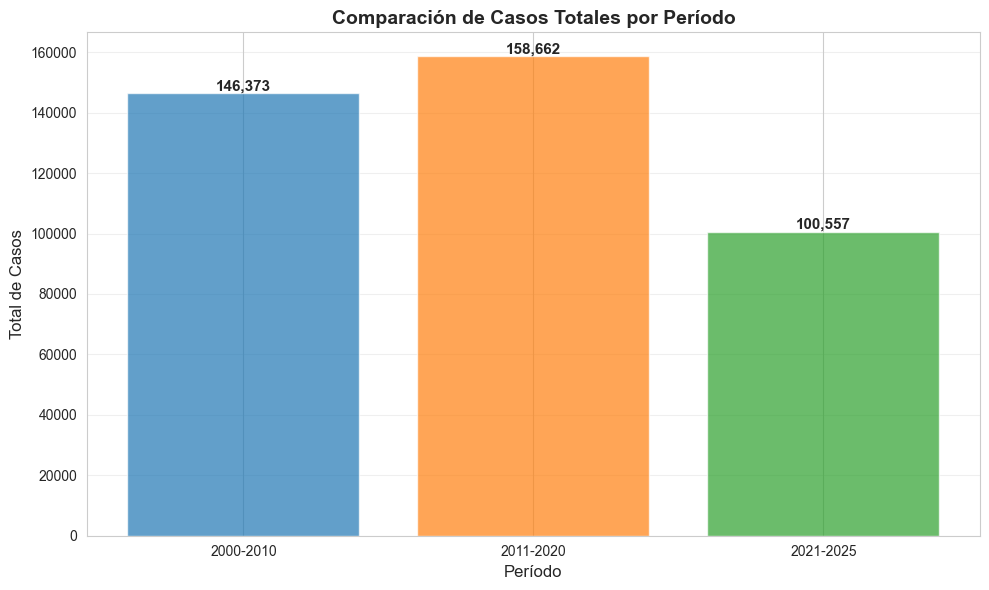

In [18]:
# Comparación: Década 2000-2010 vs 2011-2020 vs 2021-2025
print("COMPARACIÓN DE CASOS POR PERÍODO")
print("="*80)

decadas = {
    '2000-2010': (2000, 2010),
    '2011-2020': (2011, 2020),
    '2021-2025': (2021, 2025)
}

comparacion = []
for periodo, (inicio, fin) in decadas.items():
    casos_periodo = casos_semana[
        (casos_semana['Año'] >= inicio) & (casos_semana['Año'] <= fin)
    ]
    comparacion.append({
        'Período': periodo,
        'Total_Casos': casos_periodo['Valor'].sum(),
        'Promedio_Anual': casos_periodo['Valor'].sum() / (fin - inicio + 1),
        'Años': f"{inicio}-{fin}"
    })

comp_df = pd.DataFrame(comparacion)
display(comp_df)

# Visualización
plt.figure(figsize=(10, 6))
plt.bar(comp_df['Período'], comp_df['Total_Casos'], alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Período', fontsize=12)
plt.ylabel('Total de Casos', fontsize=12)
plt.title('Comparación de Casos Totales por Período', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
for i, row in comp_df.iterrows():
    plt.text(i, row['Total_Casos'], f"{int(row['Total_Casos']):,}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

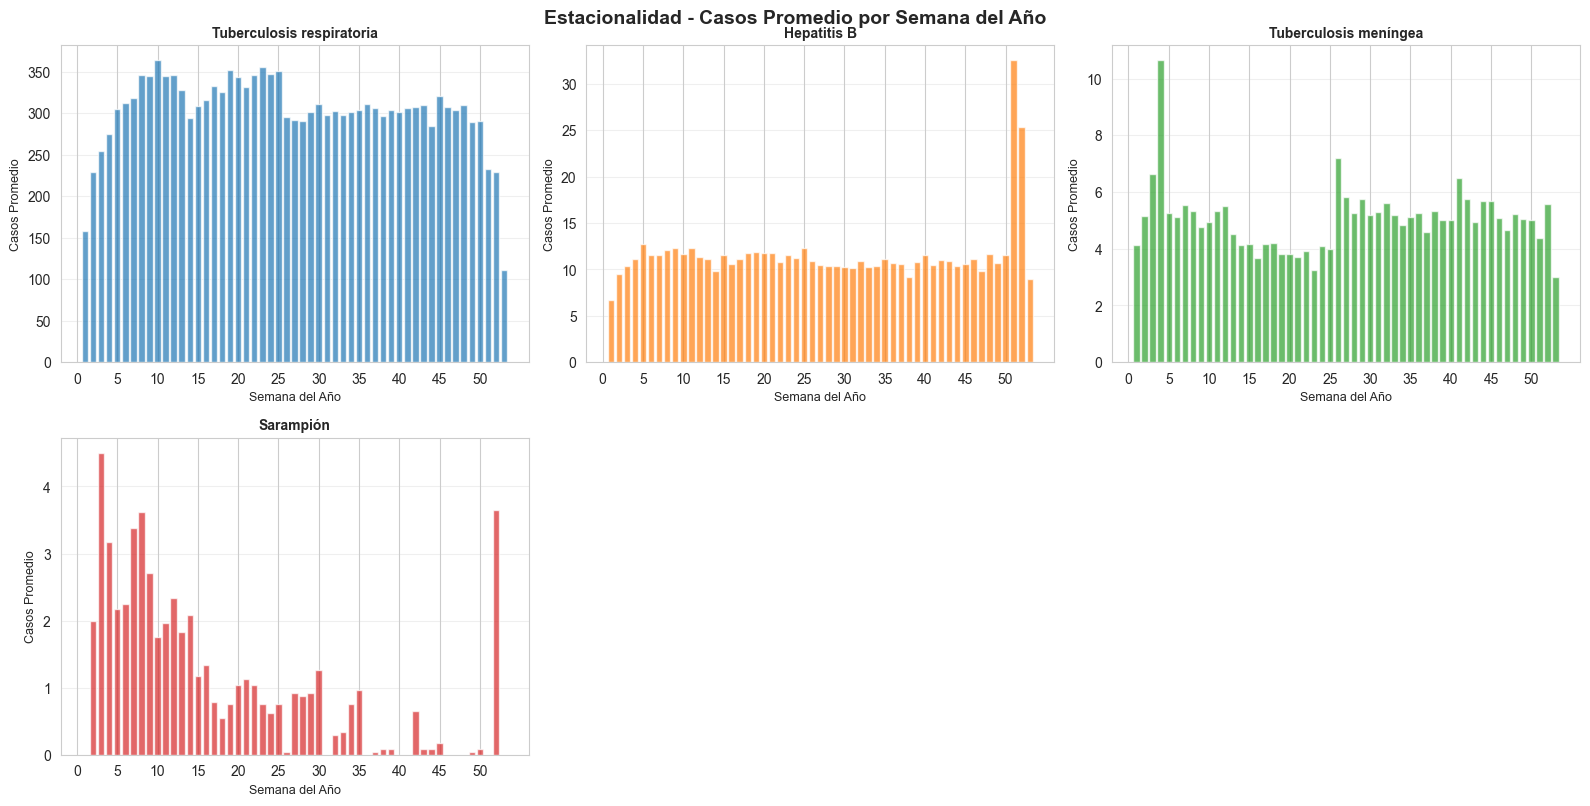

In [19]:
# Análisis de casos por semana del año (estacionalidad)
casos_por_semana = casos_semana.groupby(['Semana', 'Enfermedad'])['Valor'].mean().reset_index()

# Gráfico de calor (heatmap) para las top 5 enfermedades
plt.figure(figsize=(16, 8))

for i, enfermedad in enumerate(top_enfermedades[:5], 1):
    plt.subplot(2, 3, i)
    data_enf = casos_por_semana[casos_por_semana['Enfermedad'] == enfermedad]
    plt.bar(data_enf['Semana'], data_enf['Valor'], alpha=0.7, color=f'C{i-1}')
    plt.title(f'{enfermedad[:30]}', fontsize=10, fontweight='bold')
    plt.xlabel('Semana del Año', fontsize=9)
    plt.ylabel('Casos Promedio', fontsize=9)
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(range(0, 53, 5))

plt.tight_layout()
plt.suptitle('Estacionalidad - Casos Promedio por Semana del Año',
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

### 5.3 Análisis de Tendencias y Estacionalidad

/tmp/ipykernel_20538/238413406.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_boxplot, labels=labels_boxplot, patch_artist=True)


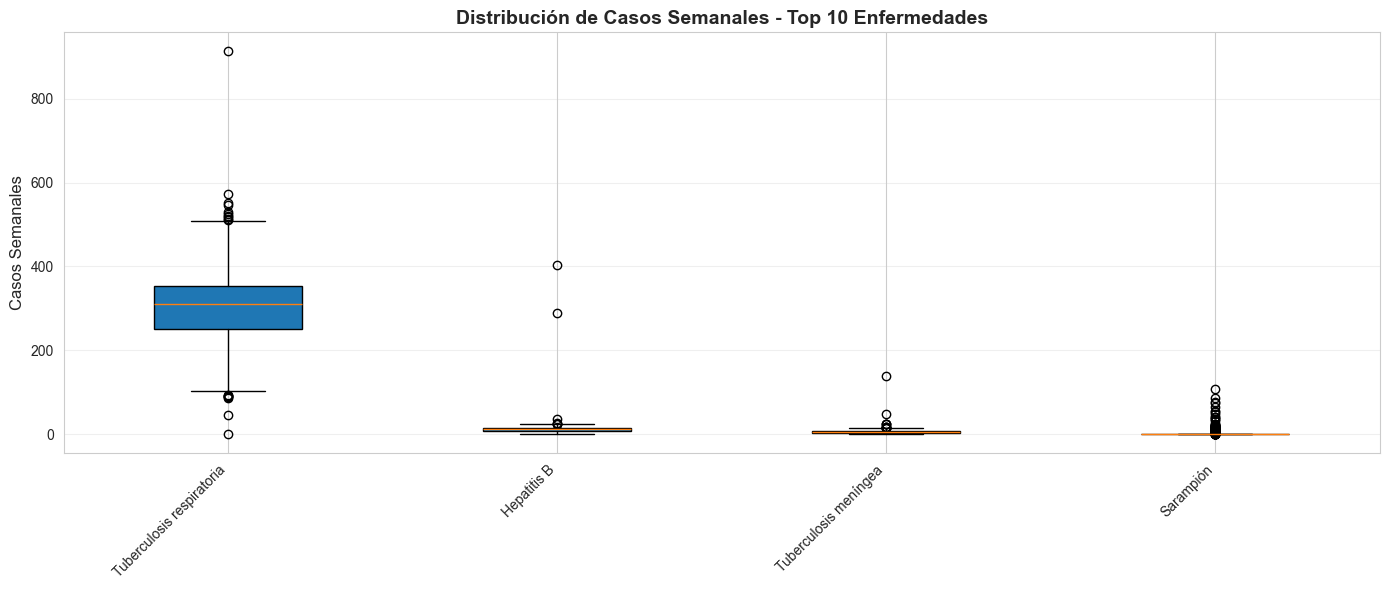

In [20]:
# Boxplot: Distribución de casos por enfermedad
plt.figure(figsize=(14, 6))

data_boxplot = []
labels_boxplot = []

for enfermedad in top_enfermedades[:10]:
    data_enf = casos_semana[casos_semana['Enfermedad'] == enfermedad]['Valor']
    data_boxplot.append(data_enf)
    labels_boxplot.append(enfermedad[:25])  # Limitar longitud del nombre

plt.boxplot(data_boxplot, labels=labels_boxplot, patch_artist=True)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Casos Semanales', fontsize=12)
plt.title('Distribución de Casos Semanales - Top 10 Enfermedades', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [21]:
# Estadísticas descriptivas por enfermedad (Top 10)
print("ESTADÍSTICAS DESCRIPTIVAS DE LAS TOP 10 ENFERMEDADES")
print("="*80)

stats_enfermedades = []
for enfermedad in top_enfermedades:
    data_enf = casos_semana[casos_semana['Enfermedad'] == enfermedad]['Valor']
    stats_enfermedades.append({
        'Enfermedad': enfermedad,
        'Total': data_enf.sum(),
        'Media': data_enf.mean(),
        'Mediana': data_enf.median(),
        'Desv_Est': data_enf.std(),
        'Min': data_enf.min(),
        'Max': data_enf.max()
    })

stats_df = pd.DataFrame(stats_enfermedades)
display(stats_df.round(2))

ESTADÍSTICAS DESCRIPTIVAS DE LAS TOP 10 ENFERMEDADES


,Enfermedad,Total,Media,Mediana,Desv_Est,Min,Max
0,Tuberculosis respiratoria,383605.0,307.38,310.0,82.30,0.0,913.0
1,Hepatitis B,14477.0,11.44,11.0,14.20,1.0,404.0
2,Tuberculosis meníngea,6218.0,5.07,4.0,5.28,0.0,138.0
3,Sarampión,1292.0,1.05,0.0,6.73,0.0,108.0


### 5.2 Análisis de Distribuciones y Estadísticas por Enfermedad

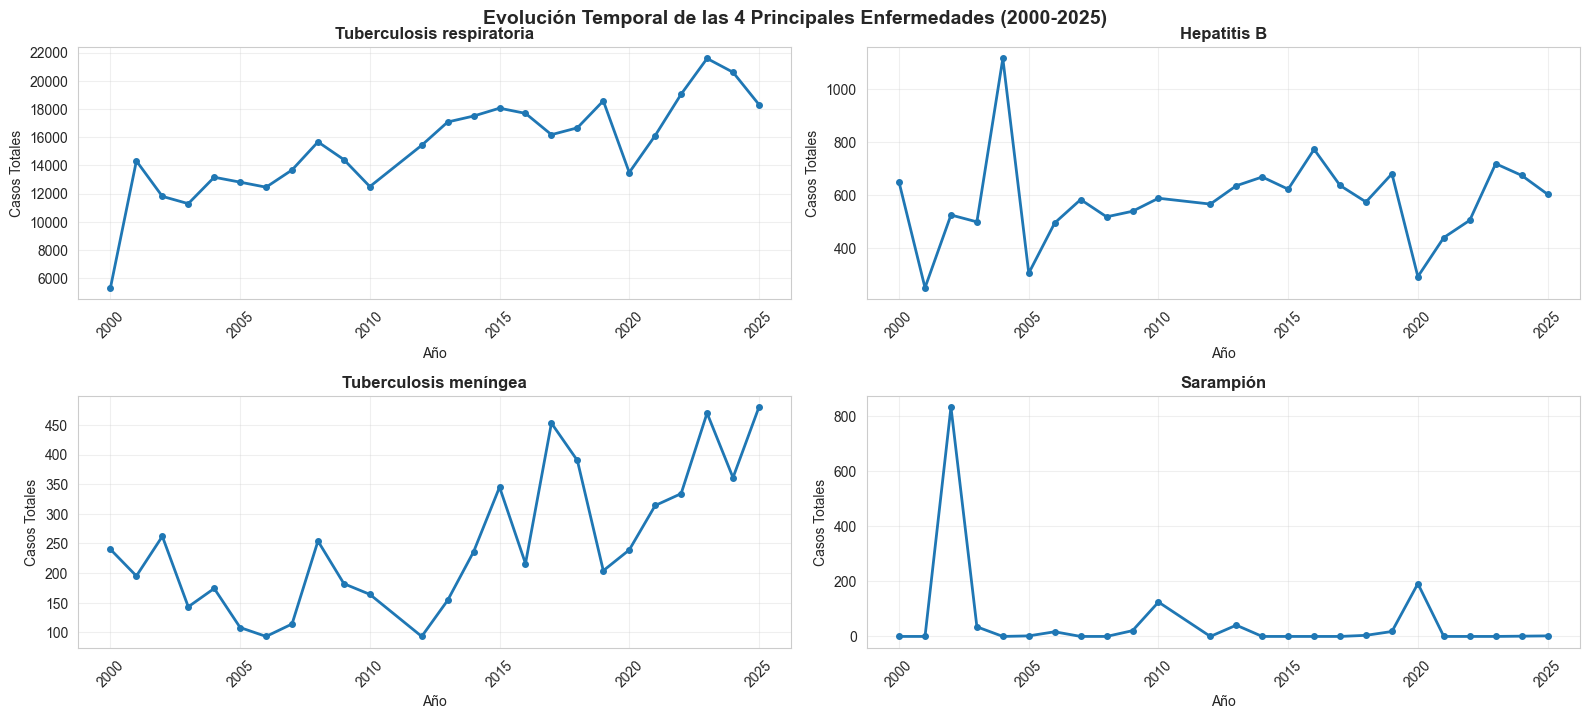

Se graficaron 4 de las 6 enfermedades principales


In [22]:
# Visualización: Evolución temporal de las principales enfermedades
plt.figure(figsize=(16, 10))

plot_count = 0
for enfermedad in top_enfermedades[:6]:
    data_enf = casos_por_año[casos_por_año['Enfermedad'] == enfermedad]

    # Solo graficar si hay datos disponibles
    if len(data_enf) > 0:
        plot_count += 1
        plt.subplot(3, 2, plot_count)
        plt.plot(data_enf['Año'], data_enf['Valor'], marker='o', linewidth=2, markersize=4)
        plt.title(f'{enfermedad}', fontsize=12, fontweight='bold')
        plt.xlabel('Año', fontsize=10)
        plt.ylabel('Casos Totales', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle(f'Evolución Temporal de las {plot_count} Principales Enfermedades (2000-2025)',
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

print(f"Se graficaron {plot_count} de las 6 enfermedades principales")

# NOTA: Solo se grafican 4 enfermedades porque las otras 2 del top 6 no tienen
# datos completos a lo largo del período 2000-2025. El código verifica que existan
# datos (len(data_enf) > 0) antes de crear cada gráfico, evitando errores por datos faltantes.